In [1]:
import sys
sys.path.append('..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from lightgbm import LGBMClassifier

from src.features import build_features

In [2]:
X, y = build_features()

for col in X.select_dtypes(include=['object', 'string']).columns:
    X[col] = X[col].astype('category')

print(X.shape, y.mean().round(4))

(307511, 142) 0.0807


In [3]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [4]:
lgbm = LGBMClassifier(n_estimators=500, learning_rate=0.05, num_leaves=31,
                      class_weight='balanced', random_state=42, verbose=-1)

scores_lgbm = cross_val_score(lgbm, X, y, cv=cv, scoring='roc_auc', n_jobs=2)

print(f"LightGBM  {scores_lgbm.mean():.4f} ± {scores_lgbm.std():.4f}")
print(f"per fold: {np.round(scores_lgbm, 4)}")

LightGBM  0.7668 ± 0.0036
per fold: [0.7628 0.7717 0.7654 0.7704 0.7635]


In [5]:
preprocessor = ColumnTransformer([
    ('num', Pipeline([('impute', SimpleImputer(strategy='median')),
                      ('scale', StandardScaler())]),
     make_column_selector(dtype_include=np.number)),
    ('cat', Pipeline([('impute', SimpleImputer(strategy='most_frequent')),
                      ('onehot', OneHotEncoder(handle_unknown='ignore'))]),
     make_column_selector(dtype_include='category')),
])

logreg = Pipeline([('prep', preprocessor),
                   ('model', LogisticRegression(max_iter=1000,
                                                class_weight='balanced'))])

scores_lr = cross_val_score(logreg, X, y, cv=cv, scoring='roc_auc', n_jobs=2)

print(f"LogReg    {scores_lr.mean():.4f} ± {scores_lr.std():.4f}")
print(f"per fold: {np.round(scores_lr, 4)}")

LogReg    0.7545 ± 0.0042
per fold: [0.75   0.7599 0.7551 0.7583 0.7494]


In [6]:
diff = scores_lgbm - scores_lr

results = pd.DataFrame({'logreg': scores_lr, 'lightgbm': scores_lgbm,
                        'difference': diff},
                       index=[f'fold {i+1}' for i in range(5)])
print(results.round(4), '\n')
print(f"Mean gain: {diff.mean():.4f} ± {diff.std():.4f}")
print(f"LightGBM wins in {(diff > 0).sum()}/5 folds")

        logreg  lightgbm  difference
fold 1  0.7500    0.7628      0.0128
fold 2  0.7599    0.7717      0.0118
fold 3  0.7551    0.7654      0.0103
fold 4  0.7583    0.7704      0.0121
fold 5  0.7494    0.7635      0.0141 

Mean gain: 0.0122 ± 0.0013
LightGBM wins in 5/5 folds


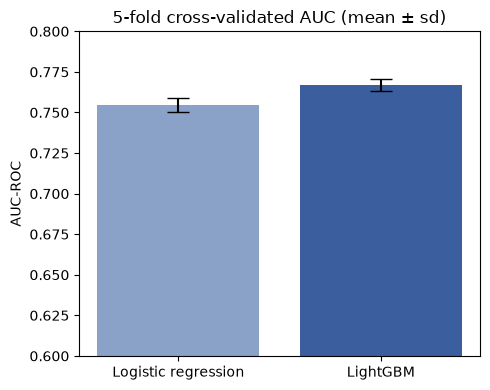

In [7]:
fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(['Logistic regression', 'LightGBM'],
       [scores_lr.mean(), scores_lgbm.mean()],
       yerr=[scores_lr.std(), scores_lgbm.std()],
       capsize=8, color=['#8aa2c8', '#3b5f9e'])
ax.set_ylabel('AUC-ROC')
ax.set_ylim(0.6, 0.8)
ax.set_title('5-fold cross-validated AUC (mean ± sd)')
plt.tight_layout()
plt.savefig('../reports/cv_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## Cross-validated comparison

Both models were evaluated with 5-fold stratified cross-validation over the full
dataset, sharing the same `StratifiedKFold` object so that the folds are identical
and only the model differs.

| Model | AUC-ROC |
|-------|---------|
| Logistic regression | 0.7545 ± 0.0042 |
| LightGBM | 0.7668 ± 0.0036 |

| Fold | LogReg | LightGBM | Difference |
|------|--------|----------|------------|
| 1 | 0.7500 | 0.7628 | 0.0128 |
| 2 | 0.7599 | 0.7717 | 0.0118 |
| 3 | 0.7551 | 0.7654 | 0.0103 |
| 4 | 0.7583 | 0.7704 | 0.0121 |
| 5 | 0.7494 | 0.7635 | 0.0141 |
| **mean** | | | **0.0122 ± 0.0013** |

Two things follow from this.

**The single-split comparison overstated the gain.** Notebook 05 reported 0.73 for
logistic regression against 0.77 for LightGBM, a gap of 0.04. Under
cross-validation the gap is 0.012. The fold-to-fold spread is only 0.004, so this
is not sampling noise: the baseline in notebook 05 was weaker than the pipeline
used here. Measuring a tuned model against a carelessly built baseline flatters
the tuned model.

**The gain that remains is real.** LightGBM wins in all five folds, and the mean
difference is about nine times its own standard deviation. Gradient boosting does
capture non-linearities and interactions that a linear model in the log-odds
cannot, and the improvement is consistent rather than fold-dependent.

Note how much tighter the paired difference is (± 0.0013) than either model's own
score (± 0.004). Fold 1 is hard for both models and fold 2 is easy for both; by
subtracting within a fold, that shared variation cancels and only the model effect
remains. This is the reason for passing one `cv` object to both estimators rather
than cross-validating them separately.

One caveat: the five training sets overlap heavily, so these standard deviations
understate the true uncertainty. There is no unbiased estimator of the variance of
k-fold cross-validation (Bengio & Grandvalet, 2004). The margin here is large
enough that this does not change the conclusion.